<font color="red">references for SAR METHOD</font>

## Overview
This notebook implements a complete SAR (Synthetic Aperture Radar) change detection pipeline using Sentinel-1 data. The workflow uses the **SAR_GSD** package to process multi-temporal SAR imagery and identify areas of persistent backscatter change, which may indicate ground deformation, construction, or land cover changes.

#### Package Structure

The analysis uses modular Python code organized in the `SAR_GSD/` package:

- **`config.py`**: Configuration management (paths, parameters, credentials)
- **`download.py`**: Data acquisition from Sentinel Hub API
- **`processing.py`**: Time series analysis and change detection
- **`visualization.py`**: Plotting and figure generation
- **`export.py`**: KML and GeoTIFF export functions

#### Configuration

All configuration is managed through the `Config` class in `SAR_GSD/config.py`:

```python
from SAR_GSD import Config

# Access configuration
print(Config.OUTPUT_DIR)
print(Config.CHANGE_THRESHOLD)

# Get predefined study area
area = Config.get_study_area('ipatinga_test')
print(area['bbox'])

# Validate credentials
if Config.validate_sentinel_hub_credentials():
    print("Credentials OK")
```

#### API Credentials

Credentials are stored in the `.env` file:

```
SENTINEL_HUB_CLIENT_ID=your_client_id
SENTINEL_HUB_CLIENT_SECRET=your_client_secret
```

Get your free Sentinel Hub credentials at: https://apps.sentinel-hub.com/dashboard/

### 1 - IMPORTS AND CONFIGURATIONS

Configure the analysis parameters:
- Area of Interest (AOI) bounding box
- Time range for data acquisition
- Spatial resolution
- Change detection threshold

In [1]:
import os
# Import the SAR_GSD package
from SAR_GSD import *

print(f"Output directory: {Config.OUTPUT_DIR}")

# Define Area of Interest (AOI) as [lon_min, lat_min, lon_max, lat_max]
AOI_BBOX = Config.DEFAULT_AOI_BBOX
print(f"AOI Bounding Box: {AOI_BBOX}")

# Temporal parameters
START_DATE = Config.DEFAULT_START_DATE
END_DATE = None  # None = use today's date
MAX_DATES = Config.MAX_DATES  # Maximum number of acquisitions to process
print(f"Start date: {START_DATE}")
print(f"Maximum dates to process: {MAX_DATES}")

# Spatial resolution in meters
RESOLUTION = Config.DEFAULT_RESOLUTION
print(f"Resolution: {RESOLUTION} m")

# Change detection threshold (log-intensity change per year)
CHANGE_THRESHOLD = Config.CHANGE_THRESHOLD
print(f"Change threshold: ±{CHANGE_THRESHOLD} log-units/year")

# Polarization
POLARIZATION = Config.POLARIZATION
print(f"Polarization: {POLARIZATION}")

print("\nConfiguration loaded from Config class.")

Output directory: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs
AOI Bounding Box: [-42.85, -19.65, -42.48, -19.4]
Start date: 2017-01-01
Maximum dates to process: 40
Resolution: 20 m
Change threshold: ±0.07 log-units/year
Polarization: VV

Configuration loaded from Config class.


### 2 - BUILD DATACUBE

- Queries Sentinel Hub for available Sentinel-1 IW GRD acquisitions
- Downloads VV polarization backscatter data for the specified AOI and time period
- Normalizes each image by its median value to reduce radiometric variations
- Builds a 3D xarray DataArray with dimensions (time, y, x)
- Includes proper geospatial coordinates and CRS (EPSG:4326)
- Saves the datacube as NetCDF format

In [ ]:
# Build the datacube using the download module
datacube, valid_dates = build_datacube(
    bbox_coords=AOI_BBOX,
    start_date=START_DATE,
    end_date=END_DATE,
    resolution=RESOLUTION,
    max_dates=MAX_DATES,
    polarization=POLARIZATION,
    normalize=True,  # Normalize by median
    verbose=True,
)

In [ ]:
# Save datacube
# datacube_path = Config.get_output_path(Config.DATACUBE_FILENAME)
datacube_path = r'C:\ProgramData\Temp\sar_datacube.nc'
save_datacube(datacube, datacube_path)

Datacube saved to: C:\ProgramData\Temp\sar_datacube2.nc
  Shape: (46, 1358, 1961)
  Variable name: 'backscatter'


### 3 - PROCESS TIME SERIES
- Applies linear regression to log-transformed backscatter time series
- Computes trend (slope) for each pixel in log-intensity units per year
- Applies spatial smoothing (Gaussian filter + mean filter) to reduce noise
- Identifies pixels with trends exceeding the threshold (±0.07 log-units/year)
- Generates binary masks for positive and negative changes
- Exports trend map and masks as GeoTIFF files

In [2]:
# If needed, now the datacube can be loaded
# datacube_path = Config.get_output_path(Config.DATACUBE_FILENAME)
datacube_path = r"C:\ProgramData\Temp\sar_datacube.nc"
datacube = xr.open_dataset(datacube_path)['backscatter']
print(f'Datacube loaded from {datacube_path}')
datacube

Datacube loaded from C:\ProgramData\Temp\sar_datacube.nc


<xarray.DataArray 'backscatter' (time: 46, y: 1358, x: 1961)> Size: 490MB
[122499748 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 368B 2017-01-03 2017-03-16 ... 2025-11-29
  * y        (y) float64 11kB -19.4 -19.4 -19.4 -19.4 ... -19.65 -19.65 -19.65
  * x        (x) float64 16kB -42.85 -42.85 -42.85 ... -42.48 -42.48 -42.48
Attributes:
    description:      Sentinel-1 VV backscatter datacube (normalized)
    units:            dimensionless (normalized to median)
    processing_date:  2026-01-18T21:34:04.953143
    source:           Sentinel Hub
    resolution_m:     20
    polarization:     VV
    start_date:       2017-01-03
    end_date:         2025-11-29
    n_acquisitions:   46
    grid_mapping:     spatial_ref

In [3]:
# Check PyTorch and CUDA availability
import torch

# Check available hardware
device = get_device(verbose=True)

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU count: 1
GPU detected: GeForce GTX 1050
GPU memory: 3.22 GB


In [5]:
# Run the complete processing pipeline
results = process_sar_timeseries(
    datacube=datacube,
    threshold=CHANGE_THRESHOLD,
    gaussian_sigma=Config.GAUSSIAN_SIGMA,
    mean_filter_size=Config.MEAN_FILTER_SIZE,
    device = device,
    verbose=True,
)

# Extract results
trend = results["trend"]
pvalues_da = results["pvalues_da"]
trend_da = results["trend_da"]
positive_mask = results["positive_mask"]
negative_mask = results["negative_mask"]
positive_mask_da = results["positive_mask_da"]
negative_mask_da = results["negative_mask_da"]
time_array = results["time_array"]

# Save trend, p-values and masks as GeoTIFF
trend_path = Config.get_output_path(Config.TREND_MAP_FILENAME)
trend_da.rio.to_raster(trend_path)
print(f"\nTrend map saved to: {trend_path}")

pvalues_path = Config.get_output_path(Config.PVALUES_MAP_FILENAME)
pvalues_da.rio.to_raster(pvalues_path)
print(f"P-values map saved to: {pvalues_path}")

pos_mask_path = Config.get_output_path(Config.POSITIVE_MASK_FILENAME)
positive_mask_da.rio.to_raster(pos_mask_path)
print(f"Positive mask saved to: {pos_mask_path}")

neg_mask_path = Config.get_output_path(Config.NEGATIVE_MASK_FILENAME)
negative_mask_da.rio.to_raster(neg_mask_path)
print(f"Negative mask saved to: {neg_mask_path}")

SAR TIME SERIES PROCESSING PIPELINE

[1/4] Computing temporal trend...
Time span: 0.00 to 8.90 years
Number of acquisitions: 46
Trend range: -0.3934 to 0.4438 log-units/year
Significant trends (p < 0.05): 1455302/2662172 (54.7%)
Highly significant (p < 0.01): 1152912/2662172 (43.3%)
Temporal trend computed in 16.21 seconds

[2/4] Applying spatial smoothing...
Applying spatial smoothing...
  Gaussian filter: sigma=1.5 pixels
  Mean filter: 3x3 kernel
  Output range: -0.2171 to 0.2342
Spatial smoothing applied in 134.40 seconds

[3/4] Detecting changes...

Change Detection Results:
  Threshold: ±0.07 log-units/year
  Positive changes: 59469 pixels (2.23%)
  Negative changes: 65560 pixels (2.46%)
  Stable areas: 2538009 pixels (95.31%)
Change detection completed in 0.01 seconds

[4/4] Creating georeferenced outputs...
Georeferenced outputs created in 2.31 seconds

✓ Processing complete!

Trend map saved to: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs\sar_trend.tif
P-values map saved

### 4 - CREATE VISUALIZATIONS

Generate figures showing:
- SAR intensity image (latest acquisition in log scale)
- Change detection overlay (intensity + colored change masks)
- Trend map with diverging colormap, and corresponding p-values for the linear regression. 
- Saves all figures as PNG files in `outputs/`

In [ ]:
# import numpy as np

# def plot_pvalues_map(
#     pvalues: np.ndarray,
#     p_threhsold: float = 0.05,
#     title: str = None,
#     figsize = None,
#     save_path= None,
#     dpi= None,
#     show: bool = True,
#     low_p_color = (0, 0, 1, 0.6),
#     high_p_color = (1, 0, 0, 0.6),
# ) -> plt.Figure:
#     """
#     Display the p-values map of temporal trend linear regression.

#     Args:
#         pvalues: 2D p-values array
#         title: Figure title
#         figsize: Figure size as (width, height) in inches. If None, uses Config.FIGURE_SIZE.
#         save_path: Path to save figure. If None, doesn't save.
#         dpi: Resolution for saved figure. If None, uses Config.DPI.
#         show: Whether to display the figure (default: True)
#         low_p_color: RGBA color for p < 0.05) (default: blue with 60% opacity)
#         high_p_color:RGBA color for p > 0.05 (default: red with 60% opacity)

#     Returns:
#         matplotlib Figure object

#     Example:
#         >>> fig = plot_trend_map(trend, threshold=0.07, save_path="outputs/trend_map.png")
#     """
#     if figsize is None:
#         figsize = Config.FIGURE_SIZE

#     if dpi is None:
#         dpi = Config.DPI

#     # Create figure
#     fig, ax = plt.subplots(figsize=figsize)

#     # Apply threshold to identify significant changes
#     high_p_mask = pvalues > p_threhsold
#     low_p_mask = pvalues < p_threhsold

#     # Create RGBA overlay array
#     overlay = np.zeros((*pvalues.shape, 4))
#     overlay[low_p_mask] = low_p_color
#     overlay[high_p_mask] = high_p_color

#     # Plot trend map
#     im = ax.imshow(overlay, aspect="auto")

#     if title is None:
#         title = (
#             f"p-values of Temporal Trend in SAR Backscatter\n"
#             f"Blue: p-values < {p_threhsold}")

#     # Set title
#     ax.set_title(title, fontsize=14, fontweight="bold")

#     # Add axis labels
#     ax.set_xlabel("Longitude (pixels)", fontsize=11)
#     ax.set_ylabel("Latitude (pixels)", fontsize=11)

#     # Tight layout
#     plt.tight_layout()

#     # Save if requested
#     if save_path:
#         print(f"Figure saved to: {save_path}")

#     # Show if requested
#     if show:
#         plt.show()

#     return fig

# fig = plot_pvalues_map(pvalues_da)

Generating figures...
  [1/3] SAR intensity image...
Figure saved to: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs/sar_intensity.png


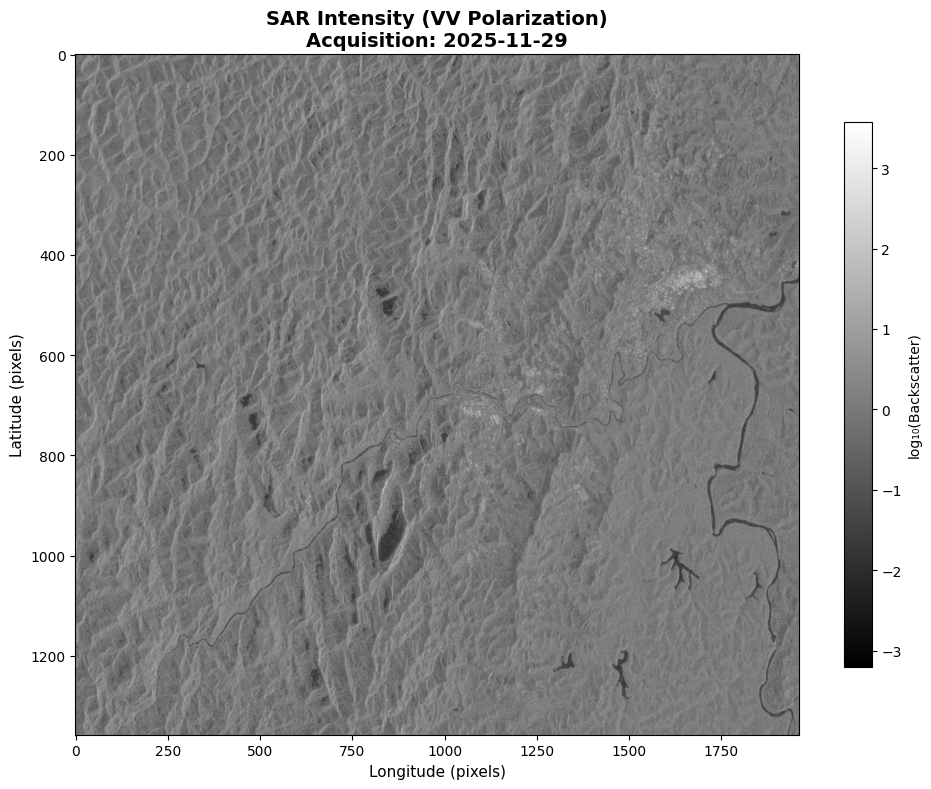

  [2/3] Change detection overlay...
Figure saved to: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs/sar_change_overlay.png


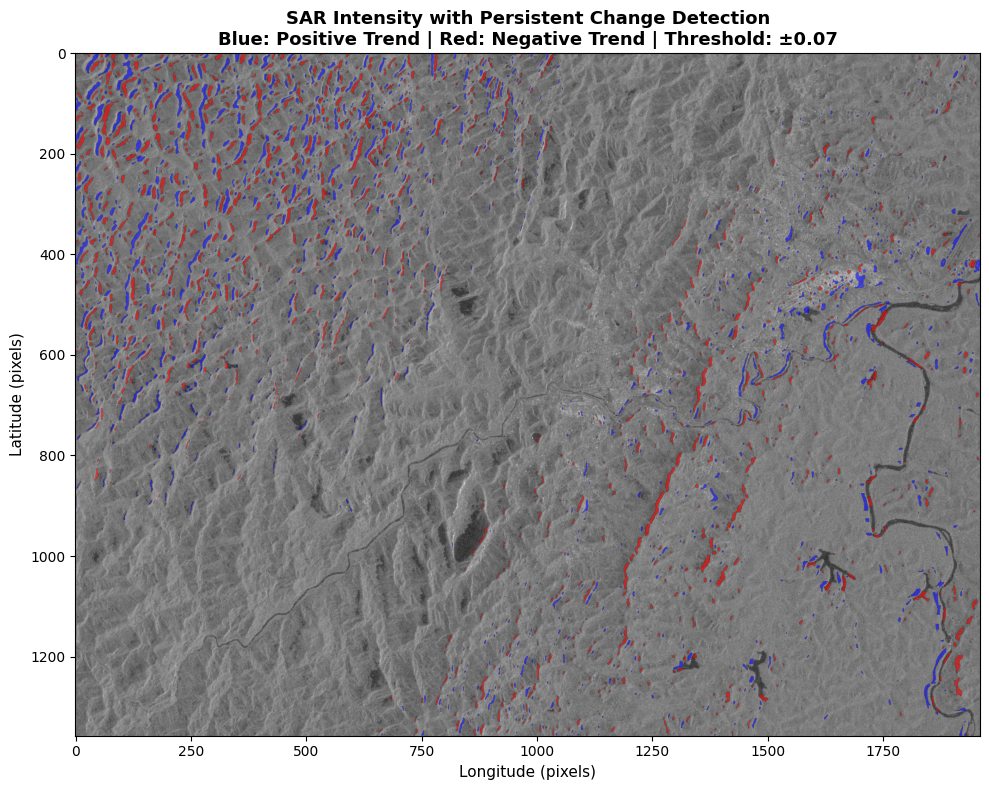

  [3/3] Trend map...
Figure saved to: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs/sar_trend_map.png


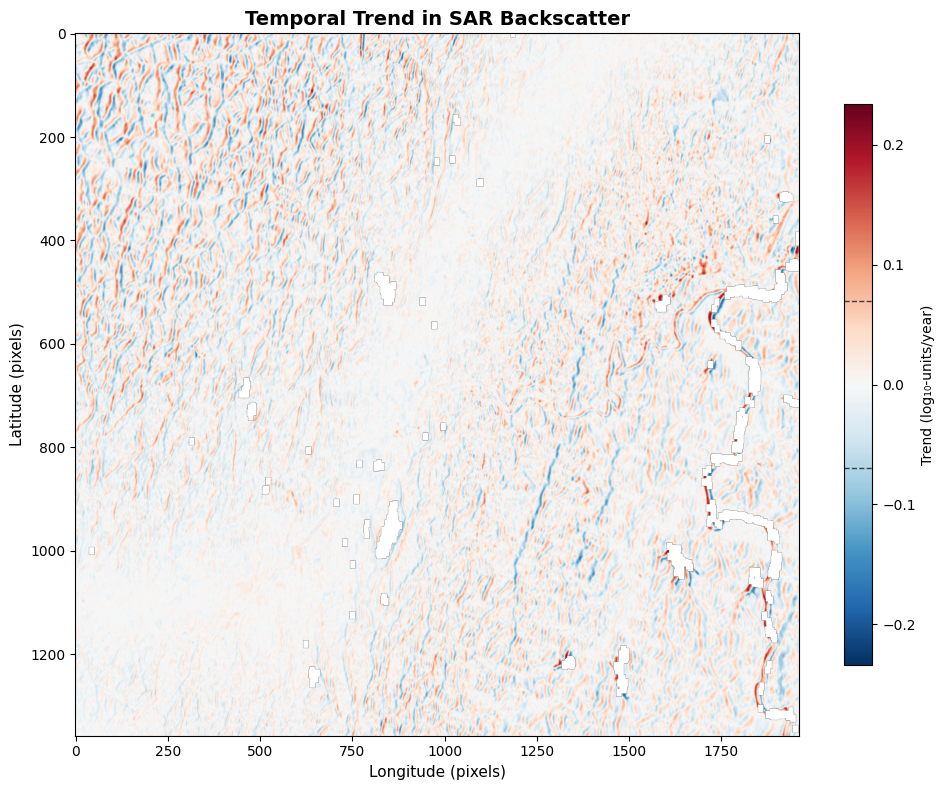

  [4/4] p-values map...
Figure saved to: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs/pvalues_map.png


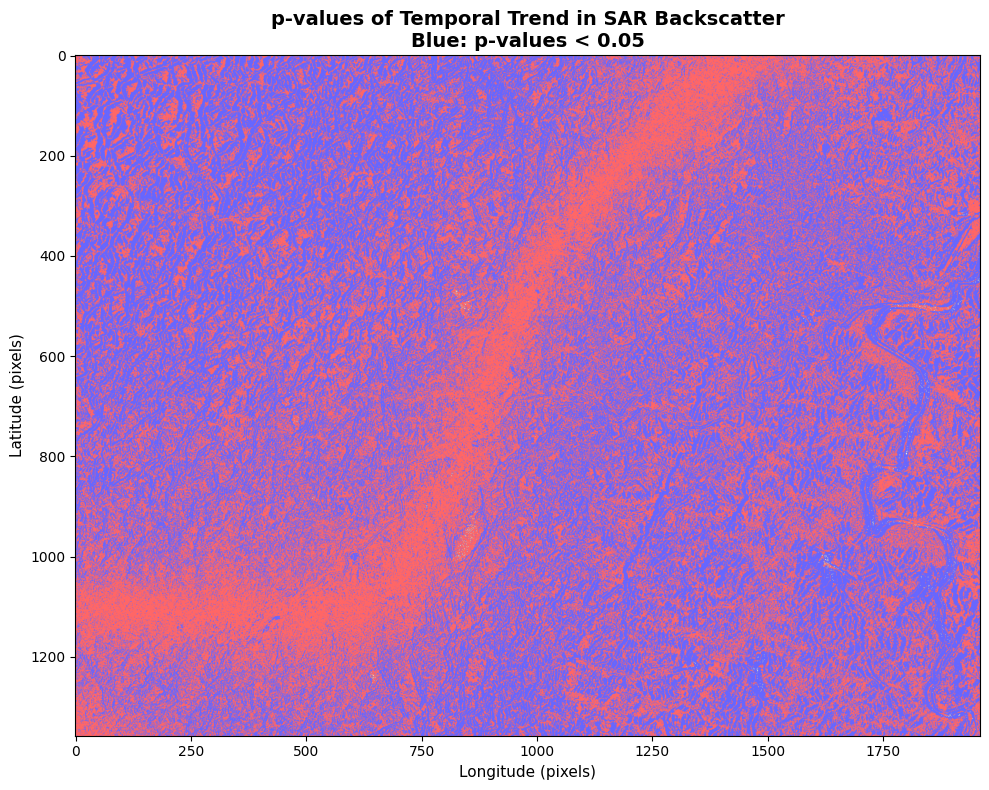

All figures generated!

All figures generated and saved!


In [6]:
# Generate all standard figures
figures = create_all_figures(
    datacube=datacube,
    trend=trend,
    pvalues=pvalues_da,
    positive_mask=positive_mask,
    negative_mask=negative_mask,
    threshold=CHANGE_THRESHOLD,
    output_dir=str(Config.OUTPUT_DIR),
    dpi=Config.DPI,
    show=True,  # Display figures in notebook
)

print("\nAll figures generated and saved!")

- **<font color='blue'>Blue areas</font>** (positive trend): Increasing backscatter (construction, vegetation growth, surface roughening)
- **<font color='red'>Red areas</font>** (negative trend): Decreasing backscatter (subsidence, deforestation, surface smoothing)

**<font color='orange'>Note</font>**: This pipeline uses log-ratio change detection with linear regression. It is sensitive to persistent temporal trends but less sensitive to rapid changes or seasonal variations. For different applications, consider adjusting the threshold, smoothing parameters, or analysis method.

### 4 - EXPORT TO KML

- Vectorizes change masks into polygons
- Creates KML file with color-coded polygons for Google Earth
- Blue polygons: positive backscatter trend (increasing intensity)
- Red polygons: negative backscatter trend (decreasing intensity)

In [ ]:
# Save all outputs (this includes KML creation)
output_files = save_all_outputs(
    datacube=datacube,
    trend_da=trend_da,
    positive_mask_da=positive_mask_da,
    negative_mask_da=negative_mask_da,
    positive_mask=positive_mask,
    negative_mask=negative_mask,
    bbox=AOI_BBOX,
    output_dir=str(Config.OUTPUT_DIR),
    verbose=True,
)

print("\nAll output files saved!")
print("\nOutput files:")
for key, path in output_files.items():
    print(f"  {key}: {path}")

<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
C:\Users\fhroc\AppData\Local\Temp\ipykernel_24228\567107494.py:10: SyntaxWarning: invalid escape sequence '\P'
  output_dir=str('C:\ProgramData\Temp\outputs'), # Config.OUTPUT_DIR



SAVING OUTPUT FILES

[1/6] Saving datacube (NetCDF)...
  ✓ C:\ProgramData\Temp\outputs\sar_datacube.nc

[2/6] Saving latest image (GeoTIFF)...
  ✓ C:\ProgramData\Temp\outputs\sar_latest.tif

[3/6] Saving trend map (GeoTIFF)...
  ✓ C:\ProgramData\Temp\outputs\sar_trend.tif

[4/6] Saving positive change mask (GeoTIFF)...
  ✓ C:\ProgramData\Temp\outputs\positive_change_mask.tif

[5/6] Saving negative change mask (GeoTIFF)...
  ✓ C:\ProgramData\Temp\outputs\negative_change_mask.tif

[6/6] Creating KML file...
Creating KML file...
  Vectorizing positive change polygons...
  Found 1600 polygons
  Vectorizing negative change polygons...
  Found 1759 polygons

✓ KML file exported: C:\ProgramData\Temp\outputs\sar_change_detection.kml
  Total polygons: 3359
    Blue (positive): 1600
    Red (negative): 1759

✓ ALL OUTPUT FILES SAVED

All output files saved!

Output files:
  datacube: C:\ProgramData\Temp\outputs\sar_datacube.nc
  latest: C:\ProgramData\Temp\outputs\sar_latest.tif
  trend: C:\Pro

### 6 - SUMMARY

In [58]:
# Create summary report
report_path = create_summary_report(
    outputs=output_files,
    datacube=datacube,
    trend_da=trend_da,
    positive_mask=positive_mask,
    negative_mask=negative_mask,
)

# Display the report
with open(report_path, "r") as f:
    print(f.read())


✓ Summary report saved: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs\summary.txt

SAR GROUND SURFACE CHANGE DETECTION - SUMMARY REPORT

DATA ACQUISITION
----------------------------------------------------------------------
  Source: Sentinel-1 VV polarization
  Date range: 2017-01-03 to 2025-11-29
  Number of acquisitions: 46
  Spatial resolution: 20 meters

TREND ANALYSIS
----------------------------------------------------------------------
  Trend range: -0.2171 to 0.2342 log-units/year
  Mean trend: 0.0001 log-units/year
  Method: Ordinary least squares regression with spatial smoothing

CHANGE DETECTION
----------------------------------------------------------------------
  Threshold: ±0.07 log-units/year
  Total pixels: 2,663,038
  Positive changes: 59,469 pixels (2.23%)
  Negative changes: 65,560 pixels (2.46%)
  Stable areas: 2,538,009 pixels

OUTPUT FILES
----------------------------------------------------------------------
  datacube: C:\ProgramData\Temp\outputs\sar_

### 7 - LAUNCH GOOGLE EARTH (OPTIONAL)

Attempt to automatically open the KML file in Google Earth Pro.
This is optional and will only work if Google Earth Pro is installed.

In [2]:
# Try to launch Google Earth with the KML file
kml_path = os.path.join(str(Config.OUTPUT_DIR), Config.KML_FILENAME)

success = launch_google_earth(kml_path, verbose=True)


✓ Launched Google Earth from: C:\Program Files\Google\Google Earth Pro\client\googleearth.exe
  Loading KML: d:\Flávio Rocha USER\OneDrive\GIT\SAR_GSD\outputs\sar_change_detection.kml


#### References

- Sentinel-1 Product Specification: https://sentinel.esa.int/web/sentinel/missions/sentinel-1
- Sentinel Hub API: https://docs.sentinel-hub.com/
